# XAI Feature Selection Analysis
## SHAP-based Feature Importance Across 5 ML Models

In [1]:
import pandas as pd
import numpy as np
import shap
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from matplotlib.patches import Rectangle
import warnings
warnings.filterwarnings('ignore')

try:
    from xgboost import XGBClassifier
    xgboost_available = True
except ImportError:
    print("Warning: XGBoost not installed. Install with: pip install xgboost")
    xgboost_available = False

plt.style.use('seaborn-v0_8-paper')
sns.set_palette("husl")

## Utility Functions

In [2]:
def process_shap_values(shap_values, select_class1=True):
    if isinstance(shap_values, list):
        shap_values_processed = shap_values[1] if select_class1 and len(shap_values) > 1 else shap_values[0]
    else:
        shap_values_processed = shap_values
    if len(shap_values_processed.shape) > 2:
        shap_values_processed = (shap_values_processed[:, :, -1]
                                if shap_values_processed.shape[2] > 1
                                else shap_values_processed[:, :, 0])
    return shap_values_processed

def compute_shap_importance(shap_values, feature_names):
    mean_abs_shap = np.abs(shap_values).mean(axis=0)
    if mean_abs_shap.ndim > 1:
        mean_abs_shap = mean_abs_shap.flatten()
    importance_df = pd.DataFrame({
        'Feature': feature_names,
        'SHAP_Importance': mean_abs_shap
    }).sort_values(by='SHAP_Importance', ascending=False)
    return importance_df

def add_gradient_legend(ax=None):
    if ax is None:
        ax = plt.gca()
    legend_x = 0.75
    legend_y = 0.05
    legend_width = 0.20
    legend_height = 0.04
    n_colors = 100
    cmap = sns.dark_palette("#69d", reverse=True, as_cmap=True)
    for i in range(n_colors):
        color = cmap(i / n_colors)
        rect = Rectangle((legend_x + i * legend_width / n_colors, legend_y),
                         legend_width / n_colors, legend_height,
                         transform=ax.transAxes, color=color,
                         clip_on=False, zorder=10)
        ax.add_patch(rect)
    ax.text(legend_x, legend_y - 0.02, 'Low', transform=ax.transAxes, fontsize=14, ha='left', va='top', fontweight='bold')
    ax.text(legend_x + legend_width, legend_y - 0.02, 'High', transform=ax.transAxes, fontsize=14, ha='right', va='top', fontweight='bold')
    ax.text(legend_x + legend_width/2, legend_y + legend_height + 0.01, 'Clinical value', transform=ax.transAxes, fontsize=14, ha='center', va='bottom', style='italic')

## Data Loading &amp; Preprocessing

In [3]:
df = pd.read_csv('feature_selection.csv')
df.loc[df['Retinopa'] == 2, 'Grau'] = df.loc[df['Retinopa'] == 2, 'Grau'].fillna(0)
df.replace(999, np.nan, inplace=True)
df.replace(9999, np.nan, inplace=True)
df = df.fillna(df.mean(numeric_only=True))

translation_dict = {
    'Etnia': 'Ethnicity', 'Idade': 'Age', 'TipoDM': 'DM_Type', 'TempoDM': 'DM_Duration',
    'HAS': 'Hypertension', 'PAS': 'SBP', 'PAD': 'DBP', 'DCV': 'CVD', 'Fumo': 'Smoking',
    'Insulina': 'Insulin', 'AntiHAS': 'Antihypertensive', 'Glicemia': 'Blood_Glucose',
    'Hb1AC': 'HbA1c', 'EUA': 'UAE', 'TFG': 'eGFR', 'ColesT': 'Total_Cholesterol', 'Grau': 'DR_Grade'
}
df = df.rename(columns=translation_dict)

drop_cols = ['ASCVD_risk','Datareti','DRD','FASE','Nascimento','Pront','RD','Retinopa','RISCO CARDIOVASCULAR CALCULADO','AnoDx','Altura','IMC','Trigli','Creat','Peso','Anoreti','IECA','Metformina','AntiDM','Sexo','Estatina','Sulfonilurreia','iSGLT2','Edema ']
df = df.drop(drop_cols, axis=1)

df['DR_Grade'] = df['DR_Grade'].astype(int)
df.loc[df['DR_Grade'].isin([0, 1]), 'DR_Grade'] = 0
df.loc[df['DR_Grade'].isin([2, 3, 4, 5]), 'DR_Grade'] = 1

X = df.drop(['DR_Grade'], axis=1)
y = df['DR_Grade']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

print(f"✓ Dataset loaded: {X.shape[0]} samples, {X.shape[1]} features")
print(f"✓ Train: {X_train.shape[0]}, Test: {X_test.shape[0]}")

✓ Dataset loaded: 1073 samples, 17 features
✓ Train: 751, Test: 322


## 1. Random Forest SHAP Analysis

In [4]:
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, max_depth=10)
rf_model.fit(X_train, y_train)

explainer_rf = shap.TreeExplainer(rf_model)
shap_values_rf = explainer_rf.shap_values(X_test)
shap_values_rf_class1 = process_shap_values(shap_values_rf)
shap_importance_rf = compute_shap_importance(shap_values_rf_class1, X.columns)

print("Random Forest - Feature Importance (Mean |SHAP|):")
print(shap_importance_rf.head(10))

Random Forest - Feature Importance (Mean |SHAP|):
              Feature  SHAP_Importance
13                UAE         0.047968
3         DM_Duration         0.043995
9             Insulin         0.031472
12              HbA1c         0.021942
5                 SBP         0.021301
14               eGFR         0.017615
1                 Age         0.013620
11      Blood_Glucose         0.010944
6                 DBP         0.010492
15  Total_Cholesterol         0.009538


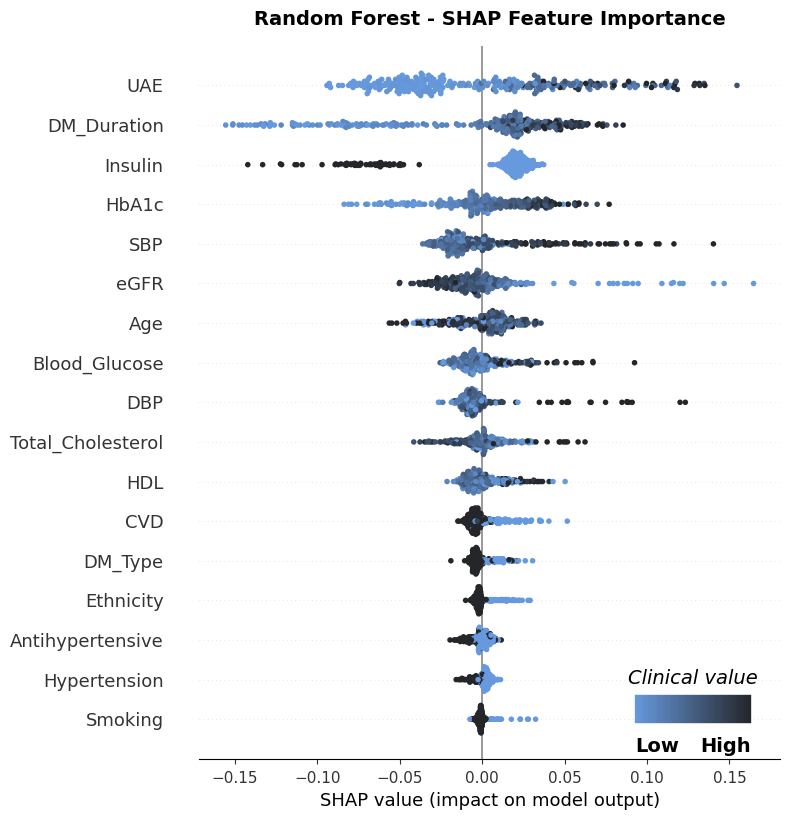

✓ Saved: rf.pdf


In [5]:
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values_rf_class1, X_test, feature_names=X.columns.tolist(),
                 plot_type="dot", show=False, color_bar=False,
                 cmap=sns.dark_palette("#69d", reverse=True, as_cmap=True))
add_gradient_legend()
plt.title('Random Forest - SHAP Feature Importance', fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('rf.pdf', dpi=300, bbox_inches='tight')
plt.show()
print("✓ Saved: rf.pdf")

## 2. Decision Tree SHAP Analysis

In [6]:
dt_model = DecisionTreeClassifier(random_state=42, max_depth=10)
dt_model.fit(X_train, y_train)

explainer_dt = shap.TreeExplainer(dt_model)
shap_values_dt = explainer_dt.shap_values(X_test)
shap_values_dt_class1 = process_shap_values(shap_values_dt)
shap_importance_dt = compute_shap_importance(shap_values_dt_class1, X.columns)

print("Decision Tree - Feature Importance (Mean |SHAP|):")
print(shap_importance_dt.head(10))

Decision Tree - Feature Importance (Mean |SHAP|):
              Feature  SHAP_Importance
13                UAE         0.095264
9             Insulin         0.069194
3         DM_Duration         0.055653
12              HbA1c         0.039504
1                 Age         0.038514
11      Blood_Glucose         0.037138
5                 SBP         0.026449
15  Total_Cholesterol         0.023410
6                 DBP         0.019213
16                HDL         0.019071


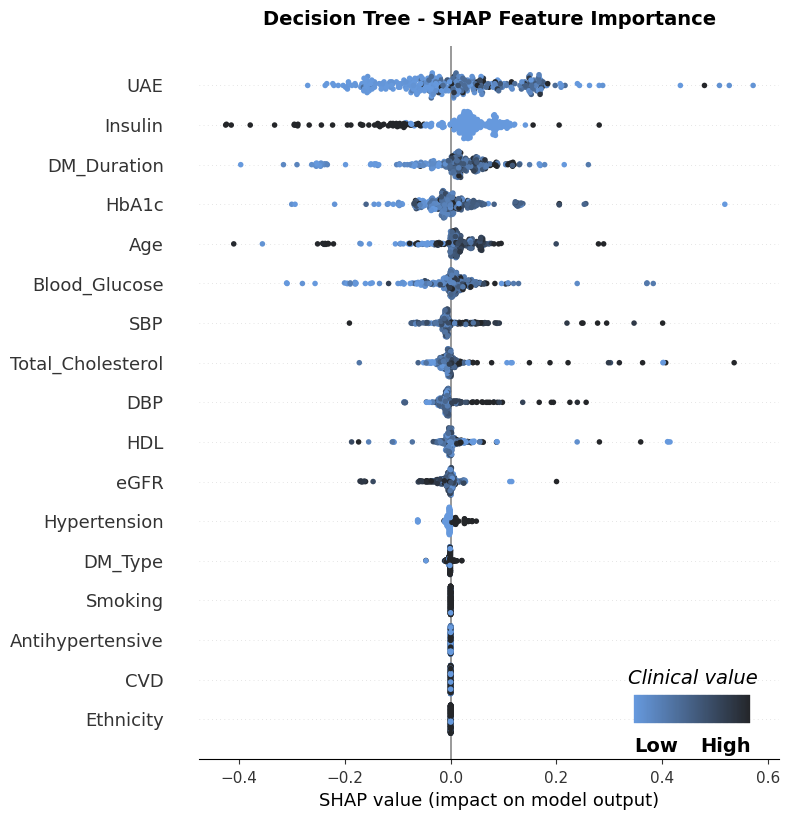

✓ Saved: dt.pdf


In [7]:
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values_dt_class1, X_test, feature_names=X.columns.tolist(),
                 plot_type="dot", show=False, color_bar=False,
                 cmap=sns.dark_palette("#69d", reverse=True, as_cmap=True))
add_gradient_legend()
plt.title('Decision Tree - SHAP Feature Importance', fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('dt.pdf', dpi=300, bbox_inches='tight')
plt.show()
print("✓ Saved: dt.pdf")

## 3. XGBoost SHAP Analysis

In [8]:
if xgboost_available:
    xgb_model = XGBClassifier(n_estimators=100, random_state=42, max_depth=6, learning_rate=0.1, eval_metric='logloss')
    xgb_model.fit(X_train, y_train, verbose=False)

    explainer_xgb = shap.TreeExplainer(xgb_model)
    shap_values_xgb = explainer_xgb.shap_values(X_test)
    shap_values_xgb_class1 = process_shap_values(shap_values_xgb)
    shap_importance_xgb = compute_shap_importance(shap_values_xgb_class1, X.columns)

    print("XGBoost - Feature Importance (Mean |SHAP|):")
    print(shap_importance_xgb.head(10))
else:
    shap_importance_xgb = pd.DataFrame({
        'Feature': X.columns,
        'SHAP_Importance': np.zeros(len(X.columns))
    })
    print("XGBoost not available")

XGBoost - Feature Importance (Mean |SHAP|):
              Feature  SHAP_Importance
3         DM_Duration         0.550631
9             Insulin         0.462939
13                UAE         0.427663
1                 Age         0.250725
5                 SBP         0.241858
14               eGFR         0.240020
12              HbA1c         0.227921
11      Blood_Glucose         0.177556
16                HDL         0.173313
15  Total_Cholesterol         0.142001


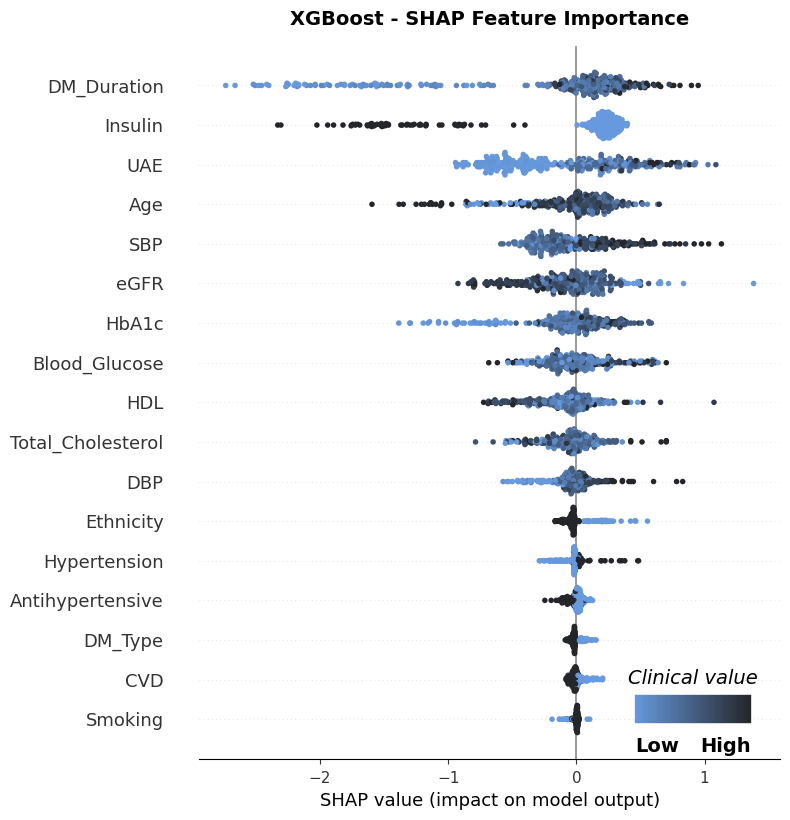

✓ Saved: xgb.pdf


In [9]:
if xgboost_available:
    plt.figure(figsize=(10, 8))
    shap.summary_plot(shap_values_xgb_class1, X_test, feature_names=X.columns.tolist(),
                     plot_type="dot", show=False, color_bar=False,
                     cmap=sns.dark_palette("#69d", reverse=True, as_cmap=True))
    add_gradient_legend()
    plt.title('XGBoost - SHAP Feature Importance', fontsize=14, fontweight='bold', pad=15)
    plt.tight_layout()
    plt.savefig('xgb.pdf', dpi=300, bbox_inches='tight')
    plt.show()
    print("✓ Saved: xgb.pdf")

## 4. Support Vector Machine SHAP Analysis

In [10]:
svm_model = SVC(kernel='rbf', probability=True, random_state=42, gamma='scale')
svm_model.fit(X_train, y_train)

X_train_summary = shap.kmeans(X_train, 50)
explainer_svm = shap.KernelExplainer(svm_model.predict_proba, X_train_summary)
X_test_sample = X_test[:100]
shap_values_svm = explainer_svm.shap_values(X_test_sample)
shap_values_svm_class1 = process_shap_values(shap_values_svm)
shap_importance_svm = compute_shap_importance(shap_values_svm_class1, X.columns)

print("SVM - Feature Importance (Mean |SHAP|):")
print(shap_importance_svm.head(10))

  0%|          | 0/100 [00:00<?, ?it/s]

SVM - Feature Importance (Mean |SHAP|):
              Feature  SHAP_Importance
13                UAE         0.001349
11      Blood_Glucose         0.000114
5                 SBP         0.000022
15  Total_Cholesterol         0.000010
14               eGFR         0.000007
3         DM_Duration         0.000006
1                 Age         0.000004
0           Ethnicity         0.000000
2             DM_Type         0.000000
8             Smoking         0.000000


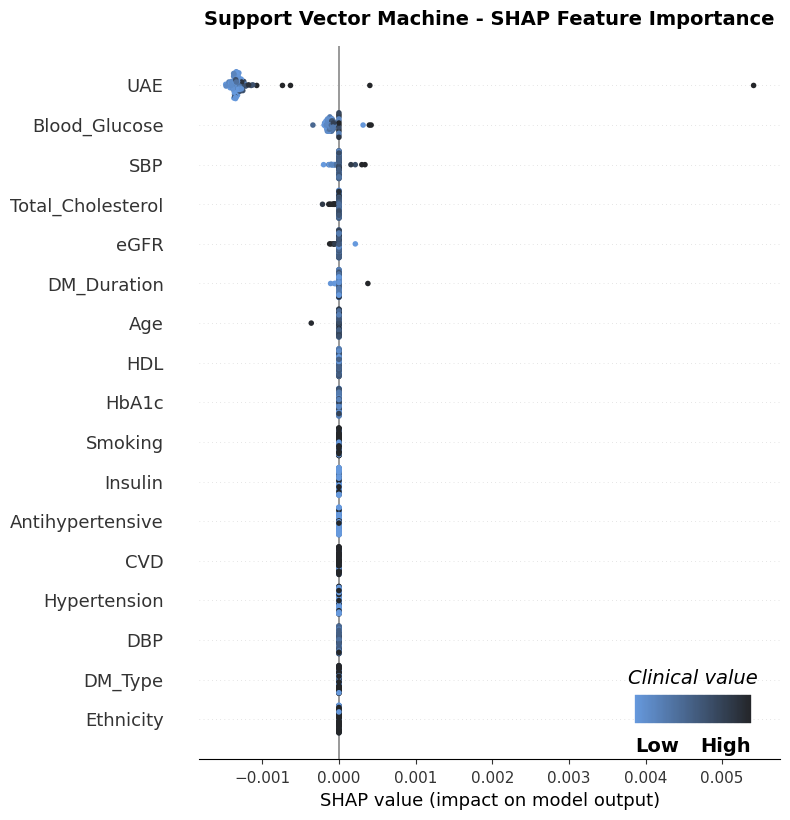

✓ Saved: svm.pdf


In [11]:
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values_svm_class1, X_test_sample, feature_names=X.columns.tolist(),
                 plot_type="dot", show=False, color_bar=False,
                 cmap=sns.dark_palette("#69d", reverse=True, as_cmap=True))
add_gradient_legend()
plt.title('Support Vector Machine - SHAP Feature Importance', fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('svm.pdf', dpi=300, bbox_inches='tight')
plt.show()
print("✓ Saved: svm.pdf")

## 5. Logistic Regression SHAP Analysis

In [12]:
scaler_lr = StandardScaler()
X_train_scaled = scaler_lr.fit_transform(X_train)
X_test_scaled = scaler_lr.transform(X_test)

lr_model = LogisticRegression(max_iter=5000, random_state=42, solver='lbfgs')
lr_model.fit(X_train_scaled, y_train)

explainer_lr = shap.LinearExplainer(lr_model, X_train_scaled)
shap_values_lr = explainer_lr.shap_values(X_test_scaled)
shap_values_lr_class1 = process_shap_values(shap_values_lr)
shap_importance_lr = compute_shap_importance(shap_values_lr_class1, X.columns)

print("Logistic Regression - Feature Importance (Mean |SHAP|):")
print(shap_importance_lr.head(10))

Logistic Regression - Feature Importance (Mean |SHAP|):
             Feature  SHAP_Importance
9            Insulin         0.560549
5                SBP         0.214721
3        DM_Duration         0.200659
14              eGFR         0.186012
12             HbA1c         0.146238
1                Age         0.130341
10  Antihypertensive         0.115937
7                CVD         0.088522
0          Ethnicity         0.051358
16               HDL         0.049101


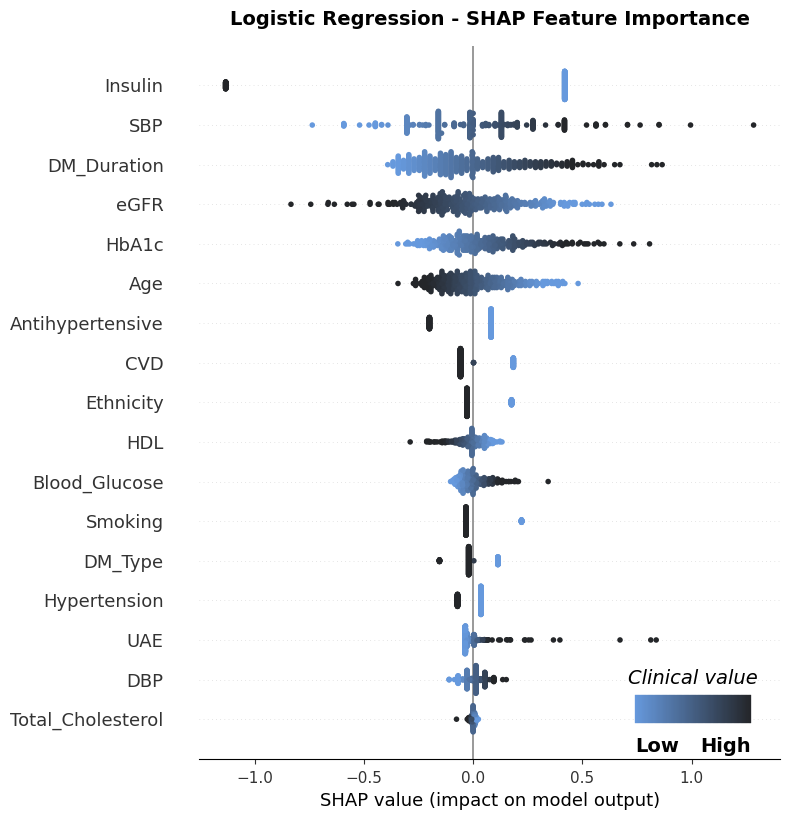

✓ Saved: lr.pdf


In [13]:
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values_lr_class1, X_test_scaled, feature_names=X.columns.tolist(),
                 plot_type="dot", show=False, color_bar=False,
                 cmap=sns.dark_palette("#69d", reverse=True, as_cmap=True))
add_gradient_legend()
plt.title('Logistic Regression - SHAP Feature Importance', fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('lr.pdf', dpi=300, bbox_inches='tight')
plt.show()
print("✓ Saved: lr.pdf")

## 6. Consolidated Feature Ranking (XAI-based - All Models)

In [14]:
scaler = MinMaxScaler()
shap_rf_normalized = scaler.fit_transform(shap_importance_rf[['SHAP_Importance']]).flatten()
shap_dt_normalized = scaler.fit_transform(shap_importance_dt[['SHAP_Importance']]).flatten()
shap_xgb_normalized = scaler.fit_transform(shap_importance_xgb[['SHAP_Importance']]).flatten()
shap_svm_normalized = scaler.fit_transform(shap_importance_svm[['SHAP_Importance']]).flatten()
shap_lr_normalized = scaler.fit_transform(shap_importance_lr[['SHAP_Importance']]).flatten()

consolidated_xai = pd.DataFrame({
    'Feature': shap_importance_rf['Feature'].values,
    'RF_SHAP': shap_rf_normalized,
    'DT_SHAP': shap_dt_normalized,
    'XGB_SHAP': shap_xgb_normalized,
    'SVM_SHAP': shap_svm_normalized,
    'LR_SHAP': shap_lr_normalized
})

consolidated_xai['XAI_Score'] = consolidated_xai[['RF_SHAP', 'DT_SHAP', 'XGB_SHAP', 'SVM_SHAP', 'LR_SHAP']].mean(axis=1)
consolidated_xai = consolidated_xai.sort_values(by='XAI_Score', ascending=False)
consolidated_xai['Rank'] = range(1, len(consolidated_xai) + 1)

consolidated_xai.to_csv('xai_feature_ranking.csv', index=False)

print("\nConsolidated XAI Feature Importance (All 5 Models):")
print(consolidated_xai.head(15).to_string())
print("\n✓ Saved: xai_feature_ranking.csv")


Consolidated XAI Feature Importance (All 5 Models):
              Feature   RF_SHAP   DT_SHAP  XGB_SHAP  SVM_SHAP   LR_SHAP  XAI_Score  Rank
0                 UAE  1.000000  1.000000  1.000000  1.000000  1.000000   1.000000     1
1         DM_Duration  0.913371  0.726346  0.837201  0.084728  0.376062   0.587542     2
2             Insulin  0.640278  0.584204  0.771712  0.016349  0.350692   0.472647     3
3               HbA1c  0.432471  0.414685  0.443230  0.007485  0.324266   0.324428     4
4                 SBP  0.418481  0.404285  0.426769  0.005073  0.252506   0.301423     5
5                eGFR  0.338114  0.389839  0.423357  0.004694  0.223825   0.275966     6
6                 Age  0.250996  0.277637  0.400895  0.002675  0.197838   0.226008     7
7       Blood_Glucose  0.192631  0.245744  0.307393  0.000000  0.148377   0.178829     8
8                 DBP  0.182790  0.201679  0.299517  0.000000  0.081326   0.153062     9
9   Total_Cholesterol  0.161977  0.200188  0.241387  0.00

## 7. Combined SHAP Visualization (All Models)

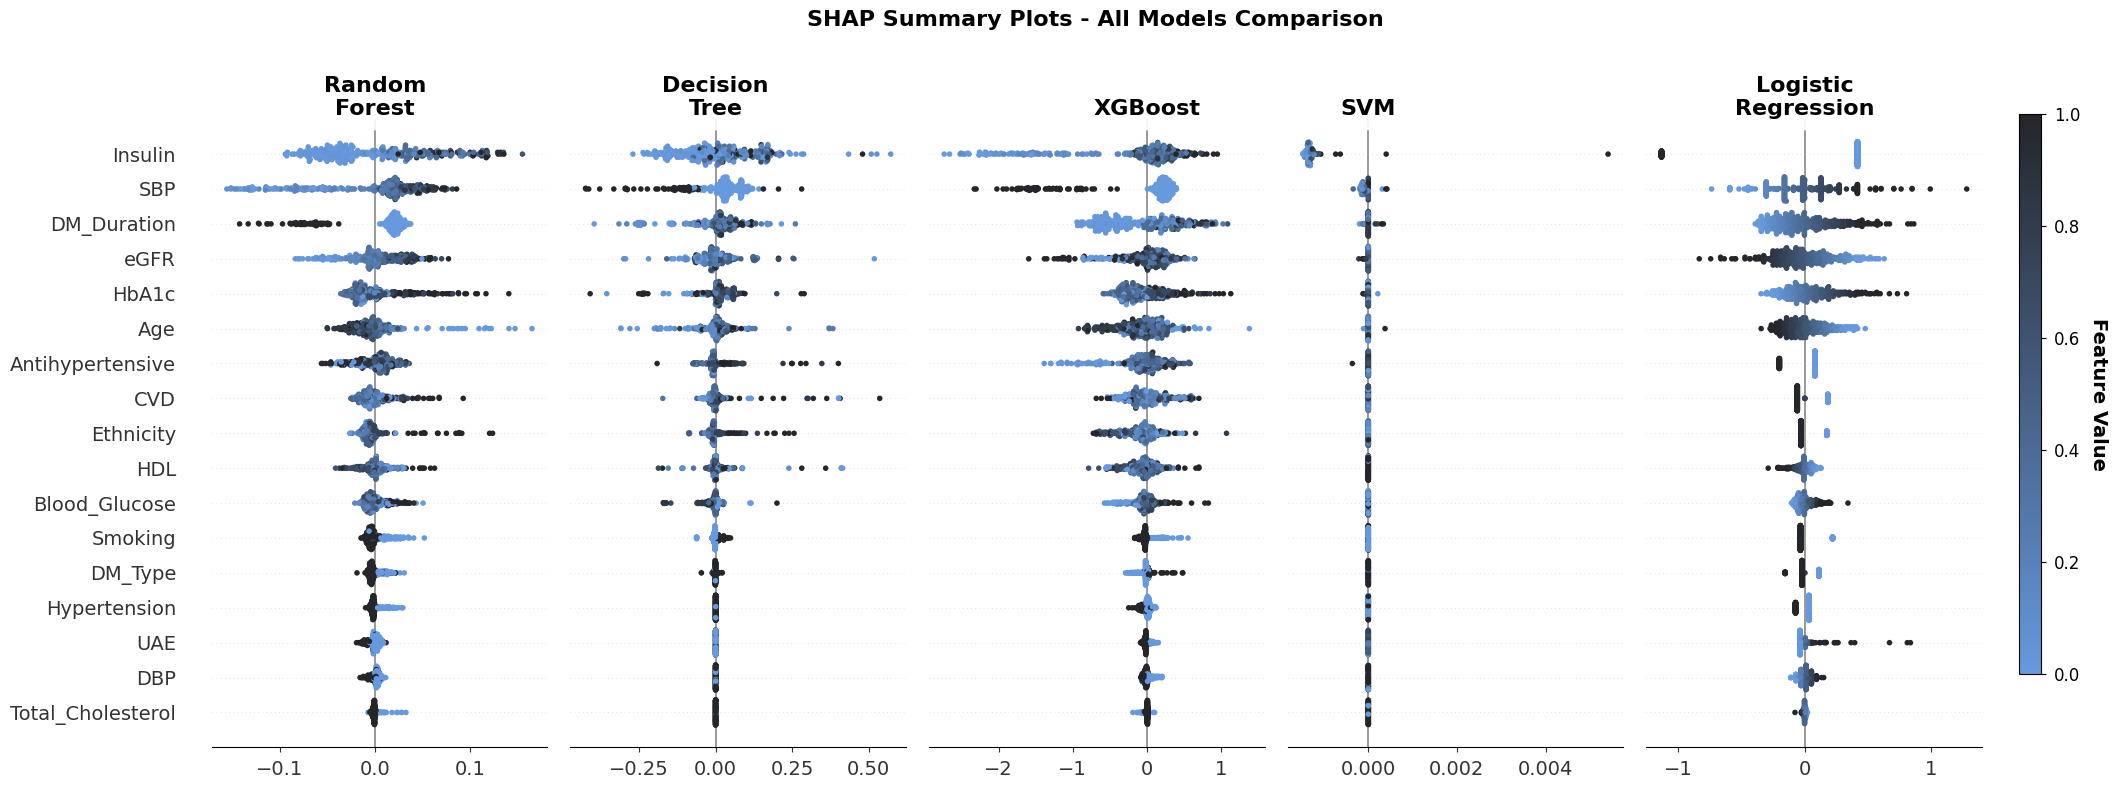

✓ Saved: shap_combined.pdf


In [15]:
fig, axes = plt.subplots(1, 5, figsize=(22, 8), sharey=True)
cmap = sns.dark_palette("#69d", reverse=True, as_cmap=True)

shap_list = [shap_values_rf_class1, shap_values_dt_class1, shap_values_xgb_class1, shap_values_svm_class1, shap_values_lr_class1]
X_list = [X_test, X_test, X_test, X_test_sample, X_test_scaled]
models = ['Random\nForest', 'Decision\nTree', 'XGBoost', 'SVM', 'Logistic\nRegression']

for idx, (ax, shap_vals, X_data, model_name) in enumerate(zip(axes, shap_list, X_list, models)):
    plt.sca(ax)
    shap.summary_plot(shap_vals, X_data, feature_names=X.columns.tolist(),
                     plot_type="dot", show=False, color_bar=False,
                     cmap=cmap, plot_size=None)
    ax.set_xlabel('', fontsize=1)
    ax.tick_params(axis='x', labelsize=14)
    ylim = ax.get_ylim()
    ax.text(0, ylim[1], model_name, fontsize=16, fontweight='bold', ha='center', va='bottom',
           bbox=dict(boxstyle='round,pad=0.5', facecolor='white', edgecolor='none', alpha=0.9))
    if idx == 0:
        ax.tick_params(axis='y', labelsize=14)
    else:
        ax.set_ylabel('')

cbar_ax = fig.add_axes([0.92, 0.15, 0.01, 0.7])
sm = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(vmin=0, vmax=1))
sm.set_array([])
cbar = fig.colorbar(sm, cax=cbar_ax)
cbar.set_label('Feature Value', rotation=270, labelpad=20, fontsize=14, fontweight='bold')
cbar.ax.tick_params(labelsize=12)

plt.suptitle('SHAP Summary Plots - All Models Comparison', fontsize=16, fontweight='bold', y=0.98)
plt.tight_layout(rect=[0, 0, 0.91, 0.96])
plt.savefig('shap_combined.pdf', dpi=300, bbox_inches='tight')
plt.show()
print("✓ Saved: shap_combined.pdf")

## 8. Comparative Heatmap (Top Features)

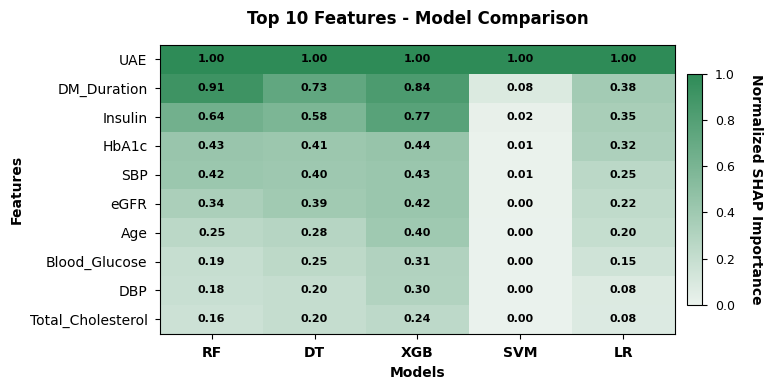

✓ Saved: heatmap.pdf


In [16]:
top_n = min(10, len(consolidated_xai))
top_features = consolidated_xai.head(top_n)
heatmap_data = top_features[['RF_SHAP', 'DT_SHAP', 'XGB_SHAP', 'SVM_SHAP', 'LR_SHAP']].values
feature_labels = top_features['Feature'].values

fig, ax = plt.subplots(figsize=(8, 4))
im = ax.imshow(heatmap_data, cmap=sns.light_palette("seagreen", as_cmap=True), aspect='auto')

ax.set_xticks(np.arange(5))
ax.set_yticks(np.arange(top_n))
ax.set_xticklabels(['RF', 'DT', 'XGB', 'SVM', 'LR'], fontsize=10, fontweight='bold')
ax.set_yticklabels(feature_labels, fontsize=10)

cbar = plt.colorbar(im, ax=ax, shrink=0.8, aspect=15, pad=0.02)
cbar.set_label('Normalized SHAP Importance', rotation=270, labelpad=20, fontsize=10, fontweight='bold')
cbar.ax.tick_params(labelsize=9)

for i in range(top_n):
    for j in range(5):
        text = ax.text(j, i, f'{heatmap_data[i, j]:.2f}',
                      ha="center", va="center", color="black", fontsize=8, fontweight='bold')

plt.title('Top 10 Features - Model Comparison', fontsize=12, fontweight='bold', pad=15)
plt.xlabel('Models', fontsize=10, fontweight='bold')
plt.ylabel('Features', fontsize=10, fontweight='bold')
plt.tight_layout()
plt.savefig('heatmap.pdf', dpi=300, bbox_inches='tight')
plt.show()
print("✓ Saved: heatmap.pdf")

## 9. Model Agreement Analysis

In [17]:
top_features_std = top_features[['RF_SHAP', 'DT_SHAP', 'XGB_SHAP', 'SVM_SHAP', 'LR_SHAP']].std(axis=1)

print("\n" + "="*80)
print("MODEL AGREEMENT ANALYSIS")
print("="*80)
print("\nConsistency of top features across models (lower std = higher agreement):")
print(f"{'Feature':<20} {'Std Dev':<12} {'Agreement':<15}")
print("-"*47)

for feature, std_val in zip(top_features['Feature'], top_features_std):
    if std_val < 0.15:
        agreement = "High ✓"
    elif std_val < 0.25:
        agreement = "Medium"
    else:
        agreement = "Low"
    print(f"{feature:<20} {std_val:<12.3f} {agreement:<15}")

print("\n" + "="*80)


MODEL AGREEMENT ANALYSIS

Consistency of top features across models (lower std = higher agreement):
Feature              Std Dev      Agreement      
-----------------------------------------------
UAE                  0.000        High ✓         
DM_Duration          0.348        Low            
Insulin              0.297        Low            
HbA1c                0.183        Medium         
SBP                  0.180        Medium         
eGFR                 0.169        Medium         
Age                  0.145        High ✓         
Blood_Glucose        0.116        High ✓         
DBP                  0.115        High ✓         
Total_Cholesterol    0.097        High ✓         



## 10. Summary &amp; Recommendations

In [18]:
print("\n" + "="*80)
print("XAI ANALYSIS SUMMARY - 5 MACHINE LEARNING MODELS")
print("="*80)

print("\nGenerated Files for Conference Paper:")
print("  ✓ rf.pdf - Random Forest SHAP Summary")
print("  ✓ dt.pdf - Decision Tree SHAP Summary")
print("  ✓ xgb.pdf - XGBoost SHAP Summary")
print("  ✓ svm.pdf - SVM SHAP Summary")
print("  ✓ lr.pdf - Logistic Regression SHAP Summary")
print("  ✓ shap_combined.pdf - All Models Comparison")
print("  ✓ heatmap.pdf - Feature Importance Heatmap")
print("  ✓ xai_feature_ranking.csv - Full Ranking Data")

print("\n" + "="*80)
print("TOP 5 RECOMMENDED FEATURES FOR CONFERENCE PAPER")
print("="*80)
print("\nBased on XAI Analysis (SHAP values from 5 models):")
print(f"{'Rank':<6} {'Feature':<25} {'XAI Score':<12} {'Agreement':<15}")
print("-"*58)

for idx, row in consolidated_xai.head(5).iterrows():
    feature = row['Feature']
    rank = int(row['Rank'])
    score = row['XAI_Score']
    if feature in top_features['Feature'].values:
        std_val = top_features[top_features['Feature'] == feature][['RF_SHAP', 'DT_SHAP', 'XGB_SHAP', 'SVM_SHAP', 'LR_SHAP']].std(axis=1).values[0]
        agreement = "High ✓" if std_val < 0.15 else "Medium" if std_val < 0.25 else "Low"
    else:
        agreement = "N/A"
    print(f"{rank:<6} {feature:<25} {score:<12.4f} {agreement:<15}")

print("\n" + "="*80)
print("These features show the highest impact on model predictions and should be")
print("prioritized for integration with retinal image analysis in your CNN model.")
print("="*80)


XAI ANALYSIS SUMMARY - 5 MACHINE LEARNING MODELS

Generated Files for Conference Paper:
  ✓ rf.pdf - Random Forest SHAP Summary
  ✓ dt.pdf - Decision Tree SHAP Summary
  ✓ xgb.pdf - XGBoost SHAP Summary
  ✓ svm.pdf - SVM SHAP Summary
  ✓ lr.pdf - Logistic Regression SHAP Summary
  ✓ shap_combined.pdf - All Models Comparison
  ✓ heatmap.pdf - Feature Importance Heatmap
  ✓ xai_feature_ranking.csv - Full Ranking Data

TOP 5 RECOMMENDED FEATURES FOR CONFERENCE PAPER

Based on XAI Analysis (SHAP values from 5 models):
Rank   Feature                   XAI Score    Agreement      
----------------------------------------------------------
1      UAE                       1.0000       High ✓         
2      DM_Duration               0.5875       Low            
3      Insulin                   0.4726       Low            
4      HbA1c                     0.3244       Medium         
5      SBP                       0.3014       Medium         

These features show the highest impact on model